### ***Flagging Vendor Invoices for Manual Review***

Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

Manual invoice review is time-consuming and does not scale with transaction volume.

Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.

An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [3]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
conn = sqlite3.connect(r'C:\Users\Skbn\OneDrive - Alliance University\Documents\Downloads\Invoice-Intelligence-System\data\inventory.db')


In [5]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
for table in tables['name']:
    print(f'Table name: {table}')
    display(pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5;", conn))

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [6]:
purchase_agg_df = pd.read_sql_query("""
                  select
                  P.PONumber,
                  count(distinct p.Brand) as total_brands,
                  sum(p.Quantity) as total_item_quantity,
                  sum(p.Dollars) as total_item_dollars,
                  avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay

                  from purchases p
                  group by P.PONumber
                  """,conn)

In [7]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p. Dollars) AS total_item_dollars,
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)
SELECT
    vi. PONumber,
    vi. Quantity AS invoice_quantity,
    vi. Dollars AS invoice_dollars,
    vi. Freight,
    (julianday(vi. InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi. PayDate) - julianday(vi. InvoiceDate) ) AS days_to_pay,
    pa. total_brands,
    pa. total_item_quantity,
    pa. total_item_dollars,
    pa.avg_receiving_delay
                  

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi. PONumber = pa.PONumber
                  
""",conn)

In [8]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [9]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [10]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [11]:
def create_invoice_risk_label(row) :
    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0
df ["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df ["flag_invoice"] . value_counts ()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

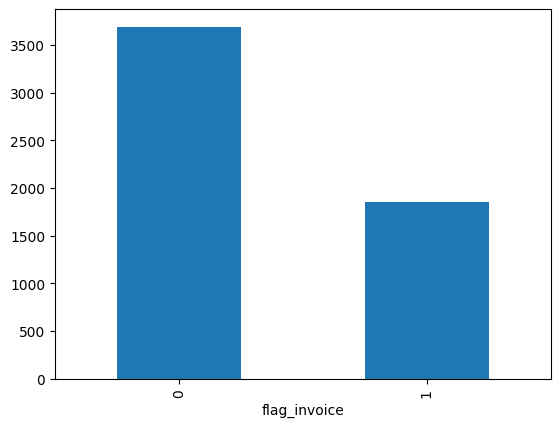

In [12]:
df['flag_invoice'].value_counts().plot(kind='bar')

In [13]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


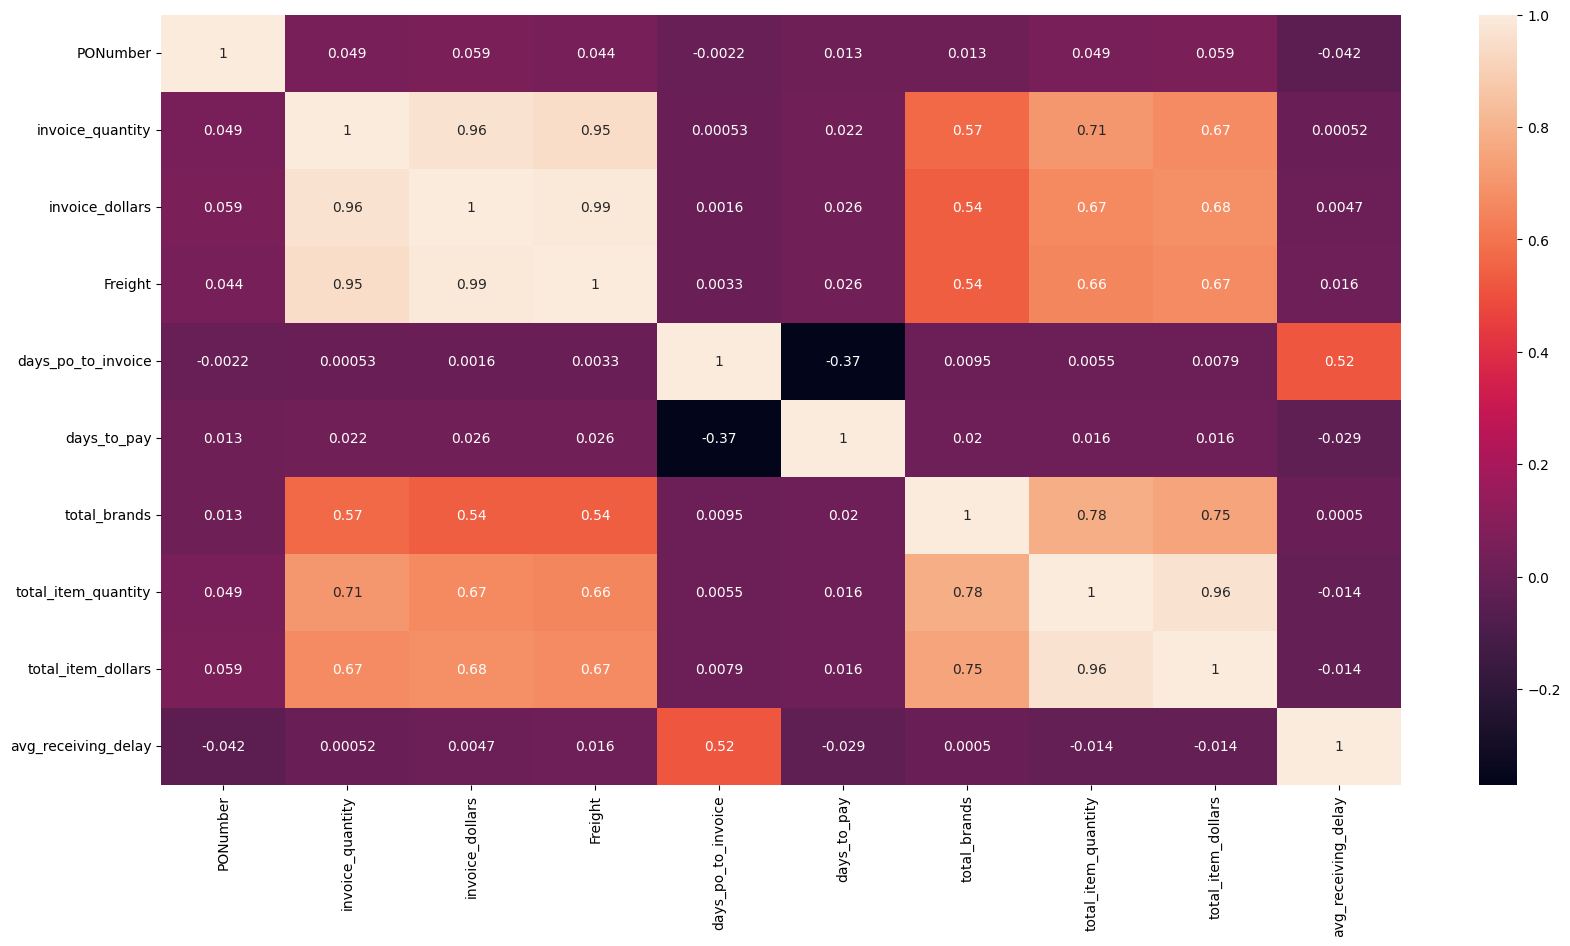

In [14]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.iloc[:, :-1].corr(),annot = True)
plt.show()

In [15]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [16]:
significant_features = []
non_significant_features = []
results = []

In [17]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
'days_po_to_invoice', 'days_to_pay', 'total_brands',
'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay' ]

In [18]:
from scipy. stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean. round(2),
            "normal_mean": normal_mean. round(2),
            "p_value": p_value. round (3)
        })
    else:
        non_significant_features.append(metric)
        print(metric)
        print({
            "metric": metric,
            "flagged_mean": flagged_mean. round(2), 
            "normal_mean": normal_mean. round(2),
            "p_value": p_value. round(3)
    })

days_to_pay
{'metric': 'days_to_pay', 'flagged_mean': np.float64(35.42), 'normal_mean': np.float64(35.49), 'p_value': np.float64(0.692)}
total_brands
{'metric': 'total_brands', 'flagged_mean': np.float64(42.29), 'normal_mean': np.float64(40.82), 'p_value': np.float64(0.508)}


In [19]:
non_significant_features

['days_to_pay', 'total_brands']

In [20]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [21]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight',
        'days_po_to_invoice', 'total_brands',
        'total_item_quantity', 'total_item_dollars']]

y = df['flag_invoice']

In [22]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_brands,total_item_quantity,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,41.0,6059.0,58073.0
std,14453.0,140234.0,714.0,3.0,77.0,14453.0,140234.0
min,1.0,4.0,0.0,9.0,1.0,1.0,4.0
25%,83.0,968.0,5.0,14.0,3.0,83.0,968.0
50%,423.0,4765.0,25.0,16.0,7.0,423.0,4765.0
75%,5100.0,44587.0,230.0,19.0,46.0,5100.0,44587.0
max,141660.0,1660436.0,8468.0,23.0,807.0,141660.0,1660436.0


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train.shape

(4434, 7)

In [25]:
y_test.shape

(1109,)

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [28]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name):
	y_pred = model.predict(X_test)
	print(f"\n{model_name}")
	print("-" * len(model_name))
	print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
	print("Confusion Matrix:")
	print(confusion_matrix(y_test, y_pred))
	print("Classification Report:")
	print(classification_report(y_test, y_pred))

evaluate_model(model1, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(model2, X_test_scaled, y_test, "Decision Tree")
evaluate_model(model3, X_test_scaled, y_test, "Random Forest")


Logistic Regression
-------------------
Accuracy: 0.6583
Confusion Matrix:
[[707  18]
 [361  23]]
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.56      0.06      0.11       384

    accuracy                           0.66      1109
   macro avg       0.61      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109


Decision Tree
-------------
Accuracy: 0.8097
Confusion Matrix:
[[625 100]
 [111 273]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       725
           1       0.73      0.71      0.72       384

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109


Random Forest
-------------
Accuracy: 0.8729
Confusion Matrix:
[[706  19]
 [122 262]]
Classification Report:
    

In [30]:
# For MINMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train) 

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
evaluate_model(model1, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(model2, X_test_scaled, y_test, "Decision Tree")
evaluate_model(model3, X_test_scaled, y_test, "Random Forest")


Logistic Regression
-------------------
Accuracy: 0.6592
Confusion Matrix:
[[709  16]
 [362  22]]
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.58      0.06      0.10       384

    accuracy                           0.66      1109
   macro avg       0.62      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109


Decision Tree
-------------
Accuracy: 0.8124
Confusion Matrix:
[[628  97]
 [111 273]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       725
           1       0.74      0.71      0.72       384

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109


Random Forest
-------------
Accuracy: 0.8729
Confusion Matrix:
[[707  18]
 [123 261]]
Classification Report:
    

In [32]:
model3.feature_importances_

array([0.14085424, 0.15759792, 0.14956964, 0.07762559, 0.08592372,
       0.16363798, 0.22479092])

In [33]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_df

,feature,importance
6,total_item_dollars,0.224791
5,total_item_quantity,0.163638
1,invoice_dollars,0.157598
2,Freight,0.149570
0,invoice_quantity,0.140854
4,total_brands,0.085924
3,days_po_to_invoice,0.077626


In [34]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

In [35]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(
random_state=42,
n_jobs =- 1
)

param_grid = {
"n_estimators": [100,200, 300],
"max_depth": [None, 4, 5, 6],
"min_samples_split": [2, 3, 5],
"min_samples_leaf": [1, 2, 5],
"criterion": ['gini' , 'entropy']
}
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
estimator=rf,
param_grid=param_grid,
scoring=scorer,
cv=5,
verbose=2,
n_jobs =-1
)

grid_search. fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier
------------------------
Accuracy: 0.8683
Confusion Matrix:
[[706  19]
 [127 257]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       725
           1       0.93      0.67      0.78       384

    accuracy                           0.87      1109
   macro avg       0.89      0.82      0.84      1109
weighted avg       0.88      0.87      0.86      1109



In [37]:
from  sklearn.metrics import  confusion_matrix
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[706, 127],
       [ 19, 257]])

In [38]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[707, 123],
       [ 18, 261]])

In [39]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 200}